In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "README.md").is_file() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").is_file():
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")


# EXP07 — CatBoost Direct Multi-Target Regression + 5-Fold CV + Optuna + OOF

`train_final_physics_v3.csv`를 입력으로 사용하여 과거 48시간(289스텝) 시계열 통계/모멘텀 피처를 추출하고, 6개 리드타임(+3h, +6h, +9h, +12h, +18h, +24h) 각각에 대해 5-Fold CatBoost 회귀기를 학습합니다.

### 파이프라인 구성
1. **시계열 표(Tabular) 피처 엔지니어링**: 기준시각($t=0$) 물리량, 단기 차분/모멘텀(1~6h), 중장기 통계량(12~48h), 파랑 역학 파생변수 추출
2. **대회 지표 맞춤형 5-Fold CV**: $h_s \ge 1.5\text{m}$ 고파랑 검증 지표(`comp_rmse`) 및 가중치(3.33배) 적용
3. **Optuna 하이퍼파라미터 최적화 (CatBoost GPU 기반)**
4. **Out-Of-Fold(OOF) 예측값 생성 및 저장 (`oof_exp07.csv`)**
5. **`test_context.parquet` 추론 및 `submission_exp07.csv` 생성**

In [1]:
# ============================================================
# 0. SETUP & PACKAGES
# ============================================================
!pip -q install optuna catboost

from pathlib import Path
import gc
import json
import warnings

import numpy as np
import pandas as pd
import catboost as cb
from sklearn.model_selection import KFold
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
def seed_everything(seed=SEED):
    np.random.seed(seed)

seed_everything()
print(f"Setup Complete. CatBoost Version: {cb.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 25.1 MB/s eta 0:00:00
Setup Complete. CatBoost Version: 1.2.10


In [2]:
# ============================================================
# 1. CONFIG
# ============================================================
DATA_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v3.csv")
TEST_CONTEXT_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_context.parquet")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")
SUBMISSION_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp07.csv")

EXP_DIR = PROJECT_ROOT / "artifacts" / "experiments" / "exp07"
EXP_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "time"
STATION_COL = "station"

STEP_MINUTES = 10
STEPS_PER_HOUR = 6

INPUT_LEN = 289
LEAD_HOURS = [3, 6, 9, 12, 18, 24]
LEAD_STEPS = [h * STEPS_PER_HOUR for h in LEAD_HOURS]
N_SPLITS = 5

print("INPUT_LEN:", INPUT_LEN)
print("LEADS:", LEAD_HOURS)

INPUT_LEN: 289
LEADS: [3, 6, 9, 12, 18, 24]


In [3]:
# ============================================================
# 2. LOAD TRAIN DATA
# ============================================================
df = pd.read_csv(DATA_PATH, parse_dates=[TIME_COL])
df = df.sort_values([STATION_COL, TIME_COL]).reset_index(drop=True)

if "hs_original_observed" not in df.columns:
    df["hs_original_observed"] = df["hs"].notna().astype(np.int8)

print("shape:", df.shape)
print("stations:", df[STATION_COL].unique())
print("period:", df[TIME_COL].min(), "~", df[TIME_COL].max())

shape: (183600, 36)
stations: ['G-ORS' 'I-ORS' 'S-ORS']
period: 2024-01-01 00:00:00+09:00 ~ 2025-06-30 23:50:00+09:00


In [4]:
# ============================================================
# 3. TABULAR FEATURE EXTRACTION FROM 48H WINDOWS
# ============================================================
def extract_window_features(window_df):
    """289스텝(48시간) 시계열 윈도우에서 머신러닝용 통계/모멘텀 피처 추출"""
    feat = {}

    # 1. 기준시각(t=0, 윈도우 마지막 시점) 원본 물리량
    last = window_df.iloc[-1]
    for col in ["hs", "tp", "hmax", "wspd", "gust", "u_wind", "v_wind", "u_wave", "v_wave",
                "wave_steepness", "wave_energy", "effective_wind_forcing",
                "wind_wave_alignment", "wind_wave_diff", "caph", "airt", "relh"]:
        if col in window_df.columns:
            feat[f"{col}_last"] = float(last[col])

    # 2. 단기 모멘텀 및 변화율 (최근 1h=6스텝, 3h=18스텝, 6h=36스텝)
    for span, name in [(6, "1h"), (18, "3h"), (36, "6h")]:
        sub = window_df.iloc[-span:]
        feat[f"hs_diff_{name}"] = float(last["hs"] - sub["hs"].iloc[0])
        feat[f"wspd_diff_{name}"] = float(last["wspd"] - sub["wspd"].iloc[0])
        feat[f"caph_diff_{name}"] = float(last["caph"] - sub["caph"].iloc[0])
        feat[f"hs_mean_{name}"] = float(sub["hs"].mean())
        feat[f"wspd_mean_{name}"] = float(sub["wspd"].mean())

    # 3. 중장기 통계량 (최근 12h=72스텝, 24h=144스텝, 48h=289스텝)
    for span, name in [(72, "12h"), (144, "24h"), (289, "48h")]:
        sub = window_df.iloc[-span:]
        for col in ["hs", "hmax", "wspd", "gust", "effective_wind_forcing", "wave_energy"]:
            if col in window_df.columns:
                feat[f"{col}_mean_{name}"] = float(sub[col].mean())
                feat[f"{col}_max_{name}"] = float(sub[col].max())
                feat[f"{col}_std_{name}"] = float(sub[col].std())

    # 4. 파랑-바람 비율 및 동역학
    feat["hmax_hs_ratio_last"] = float(last["hmax"] / max(last["hs"], 0.01))
    feat["gust_wspd_ratio_last"] = float(last["gust"] / max(last["wspd"], 0.01))
    feat["wave_age_proxy_last"] = float((1.56 * last["tp"]) / max(last["wspd"], 0.1))

    return feat

print("Feature extraction function defined.")

Feature extraction function defined.


In [ ]:
# ============================================================
# 4. BUILD TRAINING TABULAR SAMPLES (DOWN-SAMPLED STRIDE)
# ============================================================
print("Extracting training tabular samples...")
X_rows, y_rows, origin_hs_list, origin_times, station_list = [], [], [], [], []

STRIDE = 1
max_lead = max(LEAD_STEPS)

for st, g in df.groupby(STATION_COL):
    g = g.sort_values(TIME_COL).reset_index(drop=True)
    dt = pd.Series(g[TIME_COL]).diff().dt.total_seconds().div(60).to_numpy()

    for end_idx in range(INPUT_LEN - 1, len(g) - max_lead, STRIDE):
        start_idx = end_idx - INPUT_LEN + 1
        if not np.all(dt[start_idx + 1:end_idx + 1] == STEP_MINUTES):
            continue

        target_idx = [end_idx + s for s in LEAD_STEPS]
        y = g.loc[target_idx, "hs"].to_numpy(dtype=np.float32)
        obs = g.loc[target_idx, "hs_original_observed"].to_numpy(dtype=np.int8)
        if not np.isfinite(y).all() or not np.all(obs == 1):
            continue

        win_df = g.iloc[start_idx:end_idx + 1]
        feats = extract_window_features(win_df)
        feats["station"] = st

        X_rows.append(feats)
        y_rows.append(y)
        origin_hs_list.append(float(g.loc[end_idx, "hs"]))
        origin_times.append(g.loc[end_idx, TIME_COL])
        station_list.append(st)

X_train_df = pd.DataFrame(X_rows)
X_train_df = pd.get_dummies(X_train_df, columns=["station"], drop_first=False)
feature_cols = [c for c in X_train_df.columns]

Y_train_arr = np.asarray(y_rows, dtype=np.float32)
origin_hs_arr = np.asarray(origin_hs_list, dtype=np.float32)

print(f"Tabular Dataset Ready: X={X_train_df.shape}, Y={Y_train_arr.shape}")
print(f"High-wave samples (hs >= 1.5m): {(origin_hs_arr >= 1.5).sum()} / {len(origin_hs_arr)}")

Extracting training tabular samples...
Tabular Dataset Ready: X=(43200, 92), Y=(43200, 6)
High-wave samples (hs >= 1.5m): 10396 / 43200


In [6]:
# ============================================================
# 5. METRICS & CUSTOM EVALUATION
# ============================================================
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def evaluate_predictions(y_true, y_pred, origin_hs):
    overall = rmse(y_true, y_pred)
    mask = origin_hs >= 1.5
    comp = rmse(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.nan
    res = {
        "overall_rmse": overall,
        "comp_rmse": comp,
        "comp_n": int(mask.sum()),
    }
    for i, h in enumerate(LEAD_HOURS):
        res[f"rmse_{h}h"] = rmse(y_true[:, i], y_pred[:, i])
        res[f"comp_rmse_{h}h"] = rmse(y_true[mask, i], y_pred[mask, i]) if mask.sum() > 0 else np.nan
    return res

In [7]:
# ============================================================
# 6. OPTUNA TUNING FOR CATBOOST (대회 공식 통합 RMSE 정렬 버전)
# ============================================================
optuna.logging.set_verbosity(optuna.logging.INFO)
print("Starting Optuna Tuning for CatBoost with Official Competition Integrated RMSE Metric...\n")

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
sample_weights = np.where(origin_hs_arr >= 1.5, 3.33, 1.0)

def objective(trial):
    params = {
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "task_type": "GPU",
        "random_seed": SEED,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.10, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "iterations": 600,
        "early_stopping_rounds": 30,
        "verbose": False
    }

    oof_val_preds = np.zeros_like(Y_train_arr)

    for lead_idx, lead_h in enumerate(LEAD_HOURS):
        y_target = Y_train_arr[:, lead_idx]

        for train_idx, val_idx in kf.split(X_train_df):
            X_tr, y_tr, w_tr = X_train_df.iloc[train_idx], y_target[train_idx], sample_weights[train_idx]
            X_va, y_va = X_train_df.iloc[val_idx], y_target[val_idx]

            train_pool = cb.Pool(X_tr, y_tr, weight=w_tr)
            val_pool = cb.Pool(X_va, y_va)

            model = cb.CatBoostRegressor(**params)
            model.fit(train_pool, eval_set=val_pool, verbose=False)

            oof_val_preds[val_idx, lead_idx] = model.predict(X_va)

    high_mask = origin_hs_arr >= 1.5
    y_true_high = Y_train_arr[high_mask]
    y_pred_high = oof_val_preds[high_mask]

    official_integrated_comp_rmse = float(np.sqrt(np.mean((y_true_high - y_pred_high) ** 2)))
    return official_integrated_comp_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="exp07_catboost_competition_metric"
)

study.optimize(objective, n_trials=15, gc_after_trial=True)

print("\n" + "=" * 70)
print(f"BEST Competition Integrated RMSE (hs >= 1.5m, All 6 Leads): {study.best_value:.5f} m")
print("BEST PARAMS:")
print(json.dumps(study.best_params, indent=2))
print("=" * 70)

with open(EXP_DIR / "best_params.json", "w", encoding="utf-8") as f:
    json.dump(study.best_params, f, indent=2)

[I 2026-08-28 14:23:02,279] A new study created in memory with name: exp07_catboost_competition_metric


Starting Optuna Tuning for CatBoost with Official Competition Integrated RMSE Metric...



[I 2026-08-28 14:35:10,253] Trial 0 finished with value: 0.34615883231163025 and parameters: {'learning_rate': 0.03654452355213248, 'depth': 8, 'l2_leaf_reg': 8.960785365368121, 'random_strength': 0.24810409748678125}. Best is trial 0 with value: 0.34615883231163025.
[I 2026-08-28 14:38:51,849] Trial 1 finished with value: 0.4874797463417053 and parameters: {'learning_rate': 0.02570883195054889, 'depth': 4, 'l2_leaf_reg': 1.1900590783184244, 'random_strength': 2.9154431891537547}. Best is trial 0 with value: 0.34615883231163025.
[I 2026-08-28 14:46:48,929] Trial 2 finished with value: 0.33081042766571045 and parameters: {'learning_rate': 0.05262490902114903, 'depth': 7, 'l2_leaf_reg': 1.0636066512540283, 'random_strength': 7.579479953348009}. Best is trial 2 with value: 0.33081042766571045.
[I 2026-08-28 14:51:14,089] Trial 3 finished with value: 0.3557928800582886 and parameters: {'learning_rate': 0.07636290331793742, 'depth': 5, 'l2_leaf_reg': 1.7240892195821529, 'random_strength': 0


BEST Competition Integrated RMSE (hs >= 1.5m, All 6 Leads): 0.32482 m
BEST PARAMS:
{
  "learning_rate": 0.0958710116731088,
  "depth": 6,
  "l2_leaf_reg": 12.09764517626105,
  "random_strength": 0.0011032515744087822
}


In [8]:
# ============================================================
# 7. 5-FOLD MULTI-TARGET TRAINING & OOF GENERATION (CATBOOST)
# ============================================================
BEST_PARAMS = study.best_params.copy()
BEST_PARAMS.update({
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "task_type": "GPU",
    "random_seed": SEED,
    "iterations": 1800,
    "early_stopping_rounds": 50,
    "verbose": False
})

oof_predictions = np.zeros_like(Y_train_arr)
models_by_lead = {h: [] for h in LEAD_HOURS}
eval_results_by_lead = {h: [] for h in LEAD_HOURS}

print("\n===== 5-FOLD TRAINING FOR ALL 6 LEAD TIMES (CATBOOST) =====")
for lead_idx, lead_h in enumerate(LEAD_HOURS):
    print(f"\n--- Training Lead Time: +{lead_h}h (Horizon {lead_idx+1}/6) ---")
    y_target = Y_train_arr[:, lead_idx]

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_df)):
        X_tr, y_tr, w_tr = X_train_df.iloc[train_idx], y_target[train_idx], sample_weights[train_idx]
        X_va, y_va = X_train_df.iloc[val_idx], y_target[val_idx]

        train_pool = cb.Pool(X_tr, y_tr, weight=w_tr)
        val_pool = cb.Pool(X_va, y_va)

        model = cb.CatBoostRegressor(**BEST_PARAMS)
        model.fit(train_pool, eval_set=val_pool, verbose=False)

        eval_results_by_lead[lead_h].append(model.get_evals_result())
        val_pred = model.predict(X_va)
        oof_predictions[val_idx, lead_idx] = val_pred
        models_by_lead[lead_h].append(model)

    fold_comp = rmse(y_target[origin_hs_arr >= 1.5], oof_predictions[origin_hs_arr >= 1.5, lead_idx])
    print(f"Lead +{lead_h}h OOF comp_rmse: {fold_comp:.5f}")

final_metrics = evaluate_predictions(Y_train_arr, oof_predictions, origin_hs_arr)
print("\n================================================")
print("EXP07 OVERALL OOF EVALUATION METRICS")
print("================================================")
display(pd.Series(final_metrics).to_frame("value"))

oof_df = pd.DataFrame(oof_predictions, columns=[f"pred_{h}h" for h in LEAD_HOURS])
oof_df["origin_hs"] = origin_hs_arr
oof_df["origin_time"] = origin_times
oof_df.to_csv(PROJECT_ROOT / "oof" / PROJECT_ROOT / "oof" / "oof_exp07.csv", index=False)
pd.DataFrame([final_metrics]).to_csv(EXP_DIR / "final_metrics.csv", index=False)


===== 5-FOLD TRAINING FOR ALL 6 LEAD TIMES (CATBOOST) =====

--- Training Lead Time: +3h (Horizon 1/6) ---
Lead +3h OOF comp_rmse: 0.27865

--- Training Lead Time: +6h (Horizon 2/6) ---
Lead +6h OOF comp_rmse: 0.27837

--- Training Lead Time: +9h (Horizon 3/6) ---
Lead +9h OOF comp_rmse: 0.28099

--- Training Lead Time: +12h (Horizon 4/6) ---
Lead +12h OOF comp_rmse: 0.27863

--- Training Lead Time: +18h (Horizon 5/6) ---
Lead +18h OOF comp_rmse: 0.27426

--- Training Lead Time: +24h (Horizon 6/6) ---
Lead +24h OOF comp_rmse: 0.28214

EXP07 OVERALL OOF EVALUATION METRICS


,value
overall_rmse,0.281843
comp_rmse,0.278852
comp_n,10396.000000
rmse_3h,0.212384
comp_rmse_3h,0.278654
rmse_6h,0.250330
comp_rmse_6h,0.278368
rmse_9h,0.279166
comp_rmse_9h,0.280989
rmse_12h,0.294133


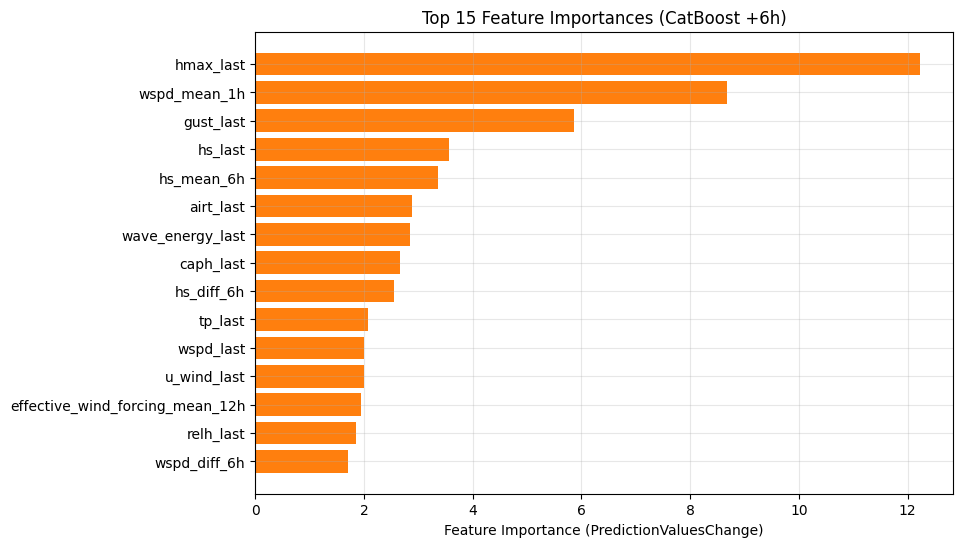

In [9]:
# ============================================================
# 8. FEATURE IMPORTANCE PLOT
# ============================================================
import matplotlib.pyplot as plt

sample_model = models_by_lead[6][0]
imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": sample_model.get_feature_importance()
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(imp_df["feature"].head(15)[::-1], imp_df["importance"].head(15)[::-1], color="#ff7f0e")
plt.xlabel("Feature Importance (PredictionValuesChange)")
plt.title("Top 15 Feature Importances (CatBoost +6h)")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# ============================================================
# 9. TEST INFERENCE & SUBMISSION CREATION
# ============================================================
print("\nRunning Test Inference on test_context.parquet...")
test_context = pd.read_parquet(TEST_CONTEXT_PATH)
test_index = pd.read_csv(TEST_INDEX_PATH)

def process_test_case(group):
    g = group.sort_values("step_minute").copy()
    st = g["station"].iloc[0]

    num_cols = ["hs", "tp", "hmax", "wspd", "gust", "airt", "relh", "caph"]
    g[num_cols] = g[num_cols].interpolate(method="linear", limit_direction="both").ffill().bfill()
    g["wdir"] = g["wdir"].ffill().bfill() % 360.0
    g["wvdir"] = g["wvdir"].ffill().bfill() % 360.0
    g["hmax"] = np.maximum(g["hmax"], g["hs"])
    g["gust"] = np.maximum(g["gust"], g["wspd"])

    wdir_rad = np.deg2rad(g["wdir"])
    wvdir_rad = np.deg2rad(g["wvdir"])
    g["u_wind"] = g["wspd"] * np.sin(wdir_rad)
    g["v_wind"] = g["wspd"] * np.cos(wdir_rad)
    g["u_wave"] = g["hs"] * np.sin(wvdir_rad)
    g["v_wave"] = g["hs"] * np.cos(wvdir_rad)

    diff = ((g["wdir"] - g["wvdir"] + 180) % 360) - 180
    g["wind_wave_diff"] = np.abs(diff)
    g["wind_wave_alignment"] = np.cos(np.deg2rad(diff))

    wl = 1.56 * (g["tp"] ** 2)
    g["wave_steepness"] = g["hs"] / np.maximum(wl, 1.0)
    g["wave_energy"] = g["hs"] ** 2
    g["effective_wind_forcing"] = (g["wspd"] ** 2) * g["wind_wave_alignment"]

    feats = extract_window_features(g)
    feats["station"] = st
    return feats

test_case_order = test_index["case_id"].drop_duplicates().tolist()
test_rows = []
for cid in test_case_order:
    grp = test_context[test_context["case_id"] == cid]
    test_rows.append(process_test_case(grp))

X_test_df = pd.DataFrame(test_rows)
X_test_df = pd.get_dummies(X_test_df, columns=["station"], drop_first=False)

for col in feature_cols:
    if col not in X_test_df.columns:
        X_test_df[col] = 0
X_test_df = X_test_df[feature_cols]

# 5-Fold 앙상블 추론
test_preds_by_lead = {}
for lead_idx, lead_h in enumerate(LEAD_HOURS):
    fold_models = models_by_lead[lead_h]
    preds_folds = [m.predict(X_test_df) for m in fold_models]
    test_preds_by_lead[lead_h] = np.mean(preds_folds, axis=0)

# 제출 형식 변환
sub_rows = []
for i, cid in enumerate(test_case_order):
    for lead_h in LEAD_HOURS:
        val = float(test_preds_by_lead[lead_h][i])
        sub_rows.append({"case_id": cid, "lead_h": lead_h, "hs_pred": val})

submission = test_index.merge(pd.DataFrame(sub_rows), on=["case_id", "lead_h"], how="left")
submission["hs_pred"] = submission["hs_pred"].clip(lower=0.0, upper=30.0)
submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8")

print("=" * 80)
print(f"EXP07 SUBMISSION SAVED: {SUBMISSION_PATH}")
print("=" * 80)
print("\nPrediction Stats:")
display(submission["hs_pred"].describe())
display(submission.head(12))


Running Test Inference on test_context.parquet...
EXP07 SUBMISSION SAVED: submission_exp07.csv

Prediction Stats:


,hs_pred
count,1200.000000
mean,1.587167
std,0.503740
min,0.425609
25%,1.235062
50%,1.553612
75%,1.883736
max,4.117482


,case_id,station,lead_h,hs_pred
0,C0001,S-ORS,3,2.612638
1,C0001,S-ORS,6,2.002519
2,C0001,S-ORS,9,1.780987
3,C0001,S-ORS,12,1.794640
4,C0001,S-ORS,18,1.683365
5,C0001,S-ORS,24,1.929425
6,C0002,I-ORS,3,1.651630
7,C0002,I-ORS,6,1.643789
8,C0002,I-ORS,9,1.515296
9,C0002,I-ORS,12,1.691917
